# Customer Sales - Advanced Clustering and Segmentation

## 1. Business Problem and Project Description
An online retailer has thousands of customers but treats all of them the same way: the same newsletter, the same discounts, the same follow-up. Marketing needs to know **which groups of customers exist**, how valuable each group is and what action fits each one (retain, reactivate, onboard).

**Objective:** Build a reproducible, end-to-end segmentation pipeline on real transactional data. Transactions are aggregated into customer-level behavioral features (RFM and beyond), processed with custom Scikit-Learn transformers, clustered with an automatically benchmarked and tuned algorithm, and finally validated **against the future**: do the segments anticipate who buys, and how much, in the following months?

**Dataset:** [Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) (UCI Machine Learning Repository, Chen, 2015). All transactions of a UK-based online retailer that sells unique all-occasion giftware, many of whose customers are wholesalers, between 01/12/2010 and 09/12/2011. The original Excel file is stored as a compressed CSV with the same columns.

**Key Workflow Steps:**
1. Data Acquisition and Transaction Cleaning
2. Temporal Design: Observation vs. Outcome Window
3. Customer-Level Feature Construction (RFM+)
4. Exploratory Data Analysis (EDA)
5. Custom Transformers and Preprocessing Pipeline
6. Optimal Number of Clusters (consensus of internal metrics)
7. Automatic Clustering Model Benchmarking
8. Hyperparameter Tuning with Optuna (adopted only if it beats the baseline)
9. Internal Validation and Stability Assessment
10. Temporal Validation and Cluster Profiling (Business Personas)

## 2. Environment Setup and Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn preprocessing and pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA

# Models for Benchmarking
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Evaluation Metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

# Hyperparameter Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Global configuration
RANDOM_STATE = 42
CUTOFF_DATE = pd.Timestamp("2011-09-01")  # Features before this date, outcomes after it

# Stock codes that are fees or adjustments, not products bought by the customer
NON_PRODUCT_CODES = {"POST", "DOT", "M", "m", "C2", "D", "S", "BANK CHARGES", "AMAZONFEE", "CRUK", "PADS", "B"}

# Styling and configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 3. Data Acquisition and Transaction Cleaning
Each row is one product line of an invoice. Before building customer features, the rows that do not represent purchasing behavior of an identifiable customer are removed, and returns are handled explicitly:

- **Missing `customer_id`:** the transaction cannot be attributed to anyone, so it cannot contribute to a customer profile.
- **Exact duplicates:** repeated lines would inflate frequency and spending.
- **Non-positive prices and non-product stock codes** (postage, bank charges, manual adjustments, discounts): they are fees or adjustments, not products the customer chose.
- **Cancellations (`invoice_no` starting with "C") are kept as negative revenue**, not dropped. Some large orders were cancelled right after being placed; dropping only the cancellation line would keep a purchase that never happened and inflate the customer's value. Spending is therefore measured as **net revenue** (purchases minus cancellations).

In [2]:
# Load the dataset (path relative to the repository, works from the root or from notebooks/)
DATA_FILE = Path("data") / "online_retail.csv.gz"
data_path = DATA_FILE if DATA_FILE.exists() else Path("..") / DATA_FILE

COLUMN_NAMES = {
    "InvoiceNo": "invoice_no", "StockCode": "stock_code", "Description": "description",
    "Quantity": "quantity", "InvoiceDate": "invoice_date", "UnitPrice": "unit_price",
    "CustomerID": "customer_id", "Country": "country"
}

def load_and_clean_transactions(filepath):
    df = pd.read_csv(filepath, dtype={"InvoiceNo": str, "StockCode": str}, parse_dates=["InvoiceDate"])
    df = df.rename(columns=COLUMN_NAMES)

    # Each cleaning rule is logged so its impact is explicit
    log = [("Raw transactions", len(df))]
    df = df.dropna(subset=["customer_id"])
    log.append(("Without missing customer_id", len(df)))
    df = df.drop_duplicates()
    log.append(("Without exact duplicates", len(df)))
    df = df[(df["unit_price"] > 0) & ~df["stock_code"].isin(NON_PRODUCT_CODES)]
    log.append(("Without non-positive prices / non-product codes", len(df)))

    # Purchases (positive quantities) and cancellations (negative revenue) are both kept
    is_cancellation = df["invoice_no"].str.startswith("C")
    df = df[is_cancellation | (df["quantity"] > 0)]

    df = df.assign(
        customer_id=df["customer_id"].astype(int),
        is_cancellation=df["invoice_no"].str.startswith("C"),
        revenue=df["quantity"] * df["unit_price"]  # Negative for cancellations
    )

    cleaning_log = pd.DataFrame(log, columns=["Step", "Rows"])
    cleaning_log["Removed"] = (-cleaning_log["Rows"].diff()).fillna(0).astype(int)
    return df.reset_index(drop=True), cleaning_log

transactions, cleaning_log = load_and_clean_transactions(data_path)
display(cleaning_log)

gross_revenue = transactions.loc[~transactions["is_cancellation"], "revenue"].sum()
cancelled_revenue = -transactions.loc[transactions["is_cancellation"], "revenue"].sum()
print(f"Clean transactions: {len(transactions):,} ({transactions['is_cancellation'].sum():,} cancellation lines) | "
      f"Customers: {transactions['customer_id'].nunique():,} | "
      f"Period: {transactions['invoice_date'].min():%Y-%m-%d} to {transactions['invoice_date'].max():%Y-%m-%d}")
print(f"Gross revenue: GBP {gross_revenue:,.0f} | Cancelled: GBP {cancelled_revenue:,.0f} ({cancelled_revenue / gross_revenue:.1%})")
display(transactions.head())

,Step,Rows,Removed
0,Raw transactions,541909,0
1,Without missing customer_id,406829,135080
2,Without exact duplicates,401604,5225
3,Without non-positive prices / non-product codes,399656,1948


Clean transactions: 399,656 (8,506 cancellation lines) | Customers: 4,362 | Period: 2010-12-01 to 2011-12-09
Gross revenue: GBP 8,737,228 | Cancelled: GBP 471,751 (5.4%)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancellation,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


## 4. Temporal Design: Observation vs. Outcome Window
Clustering has no target, so there is no classic train/test split. Instead, the timeline is split at a **cutoff date**:

- **Observation window (01/12/2010 - 31/08/2011, 9 months):** the only data used to build customer features and fit the segmentation.
- **Outcome window (01/09/2011 - 09/12/2011):** never seen by the model. It is used at the end to check whether the segments anticipate who purchases again and how much revenue they generate.

This mirrors how the segmentation would be used in production (segment today, act on the next quarter) and prevents any future information from leaking into the features.

Observation window: 2010-12-01 to 2011-08-31 | 228,436 rows | 3,349 customers
Outcome window    : 2011-09-01 to 2011-12-09 | 171,220 rows | 2,989 customers


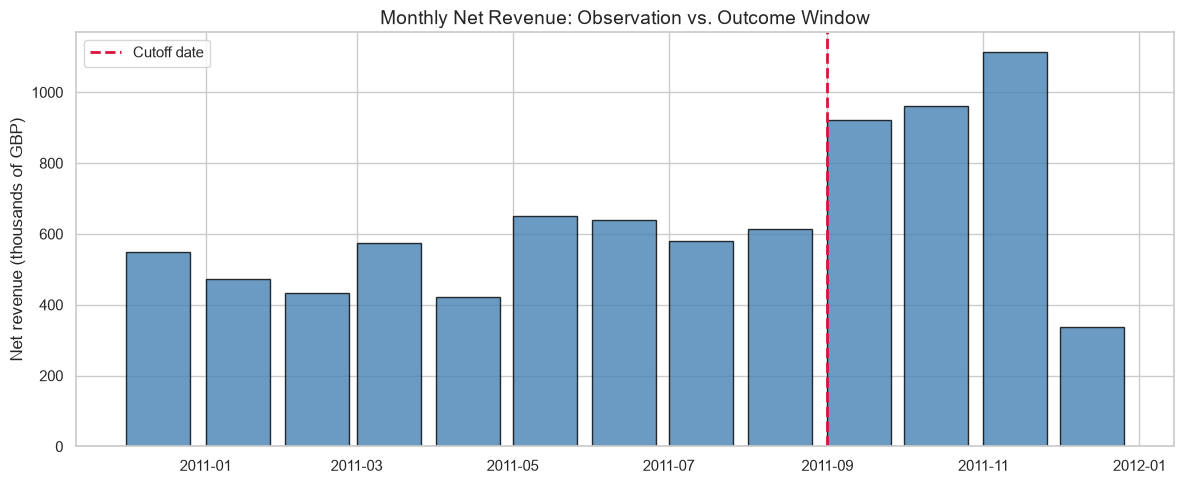

In [3]:
observation = transactions[transactions["invoice_date"] < CUTOFF_DATE]
outcome = transactions[transactions["invoice_date"] >= CUTOFF_DATE]

for name, window in [("Observation window", observation), ("Outcome window    ", outcome)]:
    print(f"{name}: {window['invoice_date'].min():%Y-%m-%d} to {window['invoice_date'].max():%Y-%m-%d} "
          f"| {len(window):,} rows | {window['customer_id'].nunique():,} customers")

# Monthly net revenue with the cutoff date
monthly_revenue = transactions.set_index("invoice_date")["revenue"].resample("MS").sum()

plt.figure(figsize=(12, 5))
plt.bar(monthly_revenue.index, monthly_revenue.values / 1e3, width=25, align='edge', color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(CUTOFF_DATE, color='crimson', linestyle='--', linewidth=2, label='Cutoff date')
plt.title("Monthly Net Revenue: Observation vs. Outcome Window", fontsize=14)
plt.ylabel("Net revenue (thousands of GBP)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Customer-Level Features (RFM+)
Transactions from the observation window are aggregated into one row per customer. On top of the classic RFM triad (Recency, Frequency, Monetary), two extra behavioral dimensions are added: **tenure** (how long the customer has been active) and **product variety**. The customer's main country is kept for profiling, not for clustering. Customers whose net revenue is not positive (everything they bought was cancelled) did not really purchase anything and are excluded.

| Feature | Definition |
|---|---|
| `recency` | Days since the last purchase (at the cutoff date) |
| `frequency` | Number of distinct invoices |
| `monetary` | Net revenue in GBP (purchases minus cancellations) |
| `tenure` | Days since the first purchase (at the cutoff date) |
| `n_products` | Number of distinct products bought |
| `country` | Most frequent country of the customer's invoices |

In [4]:
# Aggregates transactions into customer-level features, using only data before the snapshot date.
def build_customer_features(df, snapshot_date):
    purchases = df[~df["is_cancellation"]]
    grouped = purchases.groupby("customer_id")
    features = pd.DataFrame({
        "recency": (snapshot_date - grouped["invoice_date"].max()).dt.days,
        "frequency": grouped["invoice_no"].nunique(),
        "monetary": df.groupby("customer_id")["revenue"].sum().round(2),  # Net of cancellations, in cents
        "tenure": (snapshot_date - grouped["invoice_date"].min()).dt.days,
        "n_products": grouped["stock_code"].nunique(),
        "country": grouped["country"].agg(lambda s: s.mode().iat[0])
    })
    # Keep only customers with at least one purchase and positive net revenue
    return features.dropna(subset=["frequency"]).query("monetary > 0").astype({"recency": int, "frequency": int, "tenure": int, "n_products": int})

customers = build_customer_features(observation, CUTOFF_DATE)
numeric_cols = customers.select_dtypes(include=[np.number]).columns

n_buyers = observation.loc[~observation["is_cancellation"], "customer_id"].nunique()
print(f"Customers with purchases: {n_buyers:,} | Excluded (net revenue <= 0): {n_buyers - len(customers):,}")
print(f"Customer table: {customers.shape}")
display(customers.head())
display(customers[numeric_cols].describe().T.round(2))

Customers with purchases: 3,314 | Excluded (net revenue <= 0): 9
Customer table: (3305, 6)


,recency,frequency,monetary,tenure,n_products,country
customer_id,,,,,,
12347,29,5,2790.86,267,82,Iceland
12348,148,3,1167.24,258,21,Finland
12350,210,1,294.40,210,16,Norway
12352,162,4,521.18,196,24,Norway
12353,104,1,89.00,104,4,Bahrain


,count,mean,std,min,25%,50%,75%,max
recency,3305.0,92.10,76.70,0.0,27.00,72.00,146.00,273.00
frequency,3305.0,3.43,5.55,1.0,1.00,2.00,4.00,126.00
monetary,3305.0,1493.24,5652.53,2.9,252.06,535.34,1319.69,175422.94
tenure,3305.0,175.76,77.85,0.0,117.00,184.00,257.00,273.00
n_products,3305.0,49.13,66.18,1.0,13.00,29.00,62.00,1188.00


## 6. Exploratory Data Analysis (EDA)

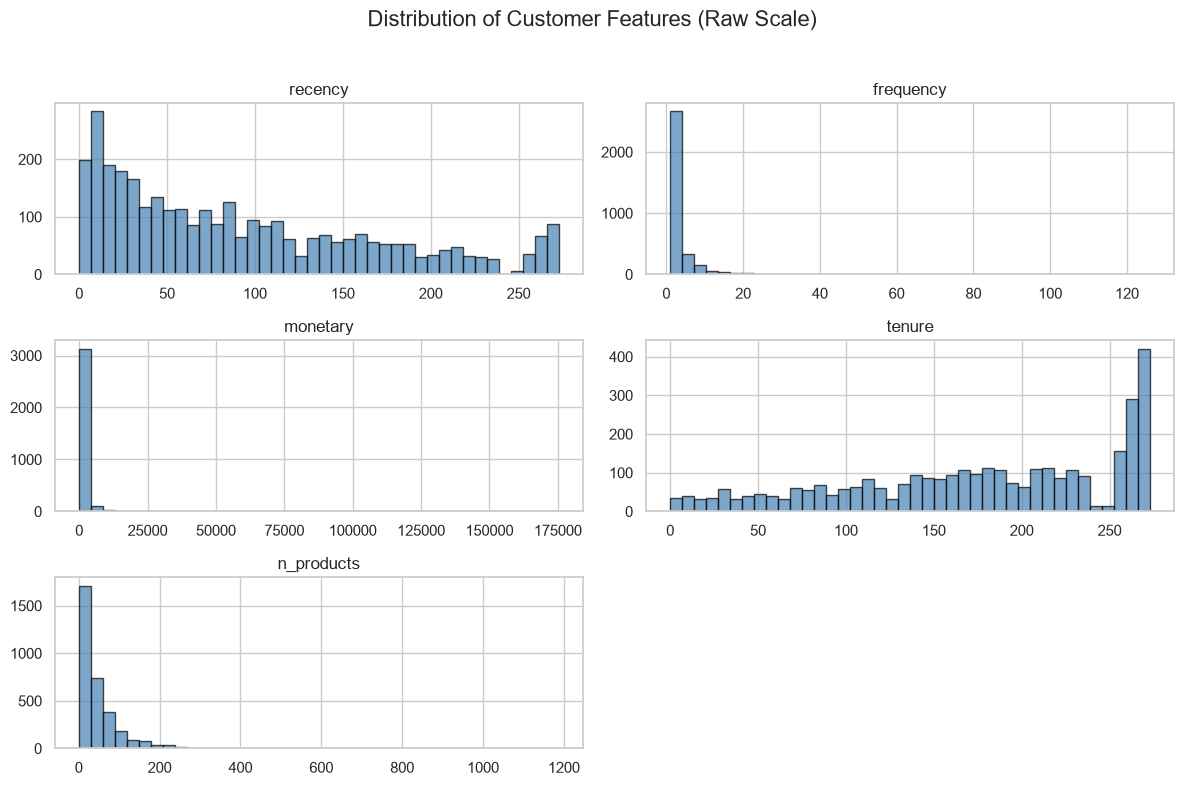

Skewness of each feature:


,Skewness
recency,0.78
frequency,9.08
monetary,17.68
tenure,-0.48
n_products,6.12


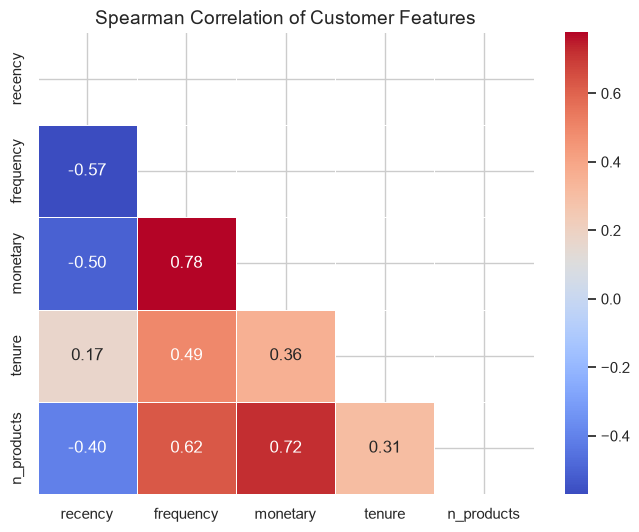

In [5]:
# Visualizing the distributions of numerical features
customers[numeric_cols].hist(bins=40, figsize=(12, 8), color='steelblue', edgecolor='black', alpha=0.7)
plt.suptitle("Distribution of Customer Features (Raw Scale)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("Skewness of each feature:")
display(customers[numeric_cols].skew().round(2).to_frame("Skewness"))

# Correlation Heatmap to understand feature relationships (Spearman: robust to the heavy tails)
plt.figure(figsize=(8, 6))
corr = customers[numeric_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title("Spearman Correlation of Customer Features", fontsize=14)
plt.show()

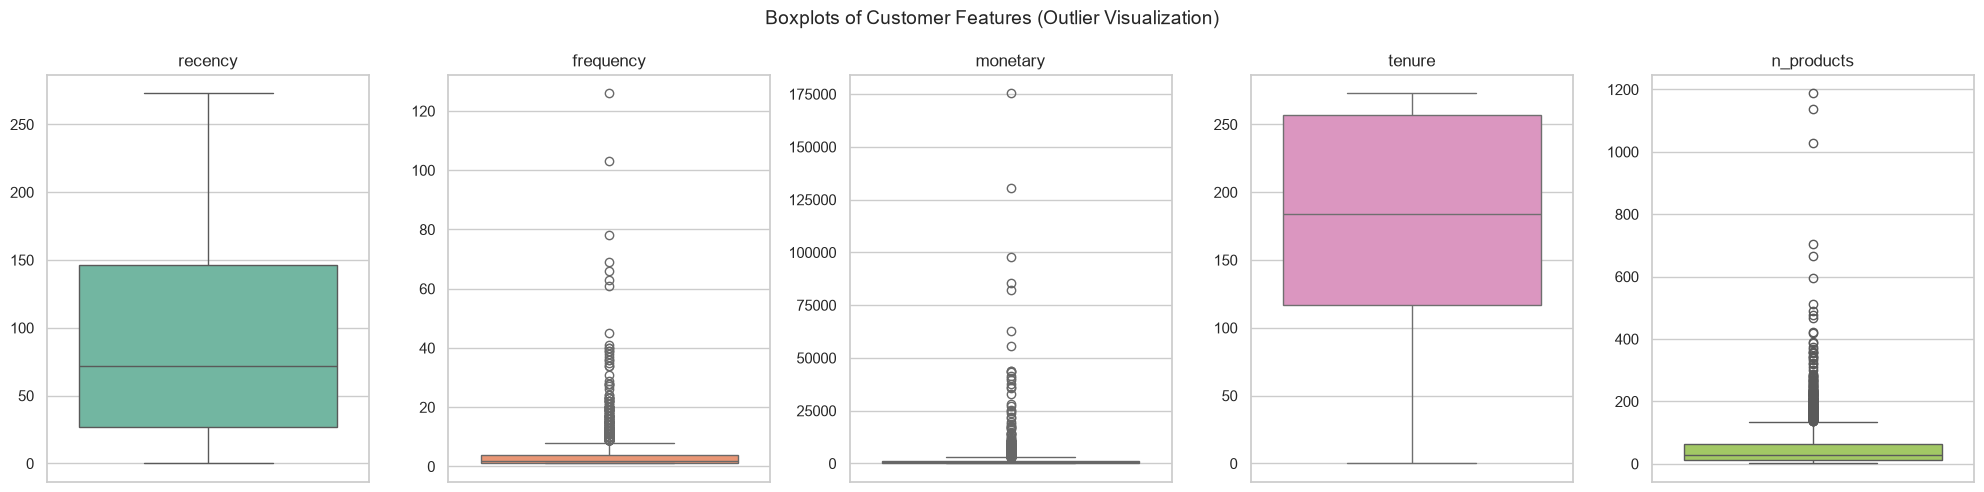

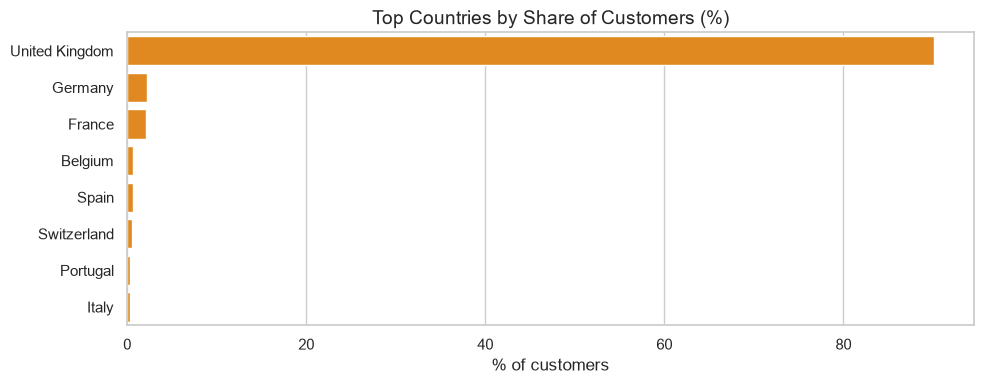

In [6]:
# Boxplots to analyze outliers. Features live on very different scales, so each one gets its own axis.
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 5))
for ax, col, color in zip(axes, numeric_cols, sns.color_palette("Set2", len(numeric_cols))):
    sns.boxplot(y=customers[col], ax=ax, color=color)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("")
plt.suptitle("Boxplots of Customer Features (Outlier Visualization)", fontsize=14)
plt.tight_layout()
plt.show()

# Market concentration: share of customers by country
country_share = customers["country"].value_counts(normalize=True).head(8) * 100
plt.figure(figsize=(10, 4))
sns.barplot(x=country_share.values, y=country_share.index, color='darkorange')
plt.title("Top Countries by Share of Customers (%)", fontsize=14)
plt.xlabel("% of customers")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Feature Engineering and Custom Transformers
Building custom Scikit-Learn transformers ensures our feature engineering steps are cleanly applied across pipelines, strictly avoiding data leakage.

`FeatureEngineer` runs **before** the `ColumnTransformer` and creates two ratios that separate *how* a customer buys from *how much*:

- **Average order value:** `avg_order_value = monetary / frequency`
- **Purchase rate:** `orders_per_month = frequency / max(tenure / 30, 1)`

In [7]:
# Custom transformer to apply domain-specific feature engineering on the customer table.
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        if {'frequency', 'monetary'}.issubset(X_out.columns):
            # Average spend per order (basket size in GBP)
            X_out["avg_order_value"] = X_out["monetary"] / X_out["frequency"].clip(lower=1)

        if {'frequency', 'tenure'}.issubset(X_out.columns):
            # Orders per active month (at least one month, so brand-new customers are not inflated)
            X_out["orders_per_month"] = X_out["frequency"] / np.maximum(X_out["tenure"] / 30, 1)

        return X_out

# Clips numerical outliers based on the Interquartile Range (IQR) method.
class IQRTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, iqr_factor=1.5):
        self.iqr_factor = iqr_factor

    def fit(self, X, y=None):
        X_array = np.asarray(X, dtype=float)
        q1 = np.nanpercentile(X_array, 25, axis=0)
        q3 = np.nanpercentile(X_array, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = q1 - self.iqr_factor * iqr
        self.upper_ = q3 + self.iqr_factor * iqr
        return self

    def transform(self, X):
        X_array = np.asarray(X, dtype=float)
        return np.clip(X_array, self.lower_, self.upper_)

# Groups infrequent categorical modalities into an 'Other' category.
class RareCategoryEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold = threshold

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.columns_ = X_df.columns
        self.rare_categories_ = {}
        for col in self.columns_:
            freqs = X_df[col].value_counts(normalize=True)
            self.rare_categories_[col] = set(freqs[freqs < self.threshold].index)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        for col in self.columns_:
            X_df[col] = X_df[col].where(~X_df[col].isin(self.rare_categories_[col]), "Other")
        return X_df.values

# Sanity check: the engineered features are actually created
display(FeatureEngineer().fit_transform(customers).head())

,recency,frequency,monetary,tenure,n_products,country,avg_order_value,orders_per_month
customer_id,,,,,,,,
12347,29,5,2790.86,267,82,Iceland,558.172,0.561798
12348,148,3,1167.24,258,21,Finland,389.080,0.348837
12350,210,1,294.40,210,16,Norway,294.400,0.142857
12352,162,4,521.18,196,24,Norway,130.295,0.612245
12353,104,1,89.00,104,4,Bahrain,89.000,0.288462


## 8. Preprocessing Pipeline Definition
All behavioral features are strongly right-skewed (a few wholesalers spend hundreds of times more than the median customer). The numerical pipeline therefore applies, in order:

1. **Median imputation** (defensive, the aggregated table has no missing values).
2. **`log1p` transform:** distances in K-Means should reflect *relative* differences (spending 2x more) rather than absolute GBP, otherwise the largest wholesalers dominate every distance.
3. **IQR clipping** on the log scale: tames the few remaining extremes without removing customers.
4. **Standard scaling:** every feature contributes on the same scale to the distance.

`country` is deliberately **excluded** from the clustering features: over 90% of customers are in the UK, and the goal is a *behavioral* segmentation. It is used later to profile the segments.

In [8]:
BEHAVIOR_FEATURES = ["recency", "frequency", "monetary", "tenure", "n_products", "avg_order_value", "orders_per_month"]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('outliers', IQRTransformer(iqr_factor=1.5)),
    ('scaler', StandardScaler()) # Crucial for distance-based clustering algorithms
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, BEHAVIOR_FEATURES)
], remainder='drop')

# Master Data Pipeline integrated
data_pipeline = Pipeline([
    ('feat_eng', FeatureEngineer()),
    ('preprocess', preprocessor)
])

## 9. Optimal Number of Clusters (k)
The pipeline is fitted on the customer table of the observation window. Then K-Means is fitted for `k = 2..8` and several internal criteria are compared: the Elbow method (inertia), Silhouette, Calinski-Harabasz and Davies-Bouldin. Each metric has its own bias, so `k` is chosen by **consensus**: the lowest average rank across the three validation indices. The outcome window is not used in this decision.

Processed feature matrix: (3305, 7)


,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin,Mean_Rank
k,,,,,
2,15120.217,0.319,1750.823,1.236,2.333
3,11888.430,0.321,1561.862,1.150,1.333
4,9824.903,0.269,1490.658,1.201,2.667
5,8650.840,0.239,1381.303,1.236,3.667
6,7969.502,0.228,1255.562,1.308,5.333
7,7403.865,0.224,1167.890,1.336,6.333
8,6872.066,0.216,1114.637,1.301,6.333


Consensus optimal number of clusters: k = 3


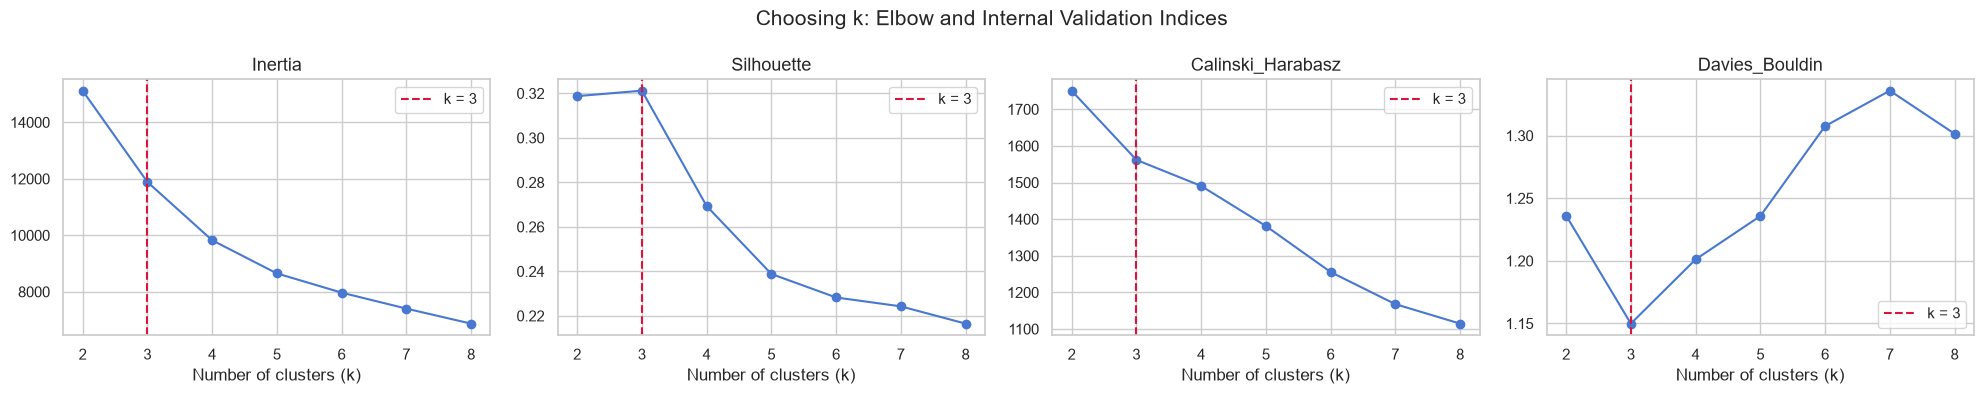

In [9]:
X_processed = data_pipeline.fit_transform(customers)
print(f"Processed feature matrix: {X_processed.shape}")

k_range = range(2, 9)
k_results = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_processed)
    k_results.append({
        'k': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X_processed, km.labels_),
        'Calinski_Harabasz': calinski_harabasz_score(X_processed, km.labels_),
        'Davies_Bouldin': davies_bouldin_score(X_processed, km.labels_)
    })
k_results = pd.DataFrame(k_results).set_index('k')

# Consensus: average rank across the validation indices (lower is better)
k_results['Mean_Rank'] = (
    k_results['Silhouette'].rank(ascending=False)
    + k_results['Calinski_Harabasz'].rank(ascending=False)
    + k_results['Davies_Bouldin'].rank(ascending=True)
) / 3
OPTIMAL_K = int(k_results['Mean_Rank'].idxmin())

display(k_results.round(3))
print(f"Consensus optimal number of clusters: k = {OPTIMAL_K}")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, metric in zip(axes, ['Inertia', 'Silhouette', 'Calinski_Harabasz', 'Davies_Bouldin']):
    ax.plot(k_results.index, k_results[metric], marker='o')
    ax.axvline(OPTIMAL_K, color='crimson', linestyle='--', label=f'k = {OPTIMAL_K}')
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Number of clusters (k)')
    ax.legend()
plt.suptitle("Choosing k: Elbow and Internal Validation Indices", fontsize=15)
plt.tight_layout()
plt.show()

## 10. Automatic Clustering Model Benchmarking
We dynamically evaluate multiple clustering architectures using the consensus `k` found in the previous step. The benchmark incorporates multiple professional metrics (Silhouette Score, Calinski-Harabasz, and Davies-Bouldin) to determine the algorithm that best captures the intrinsic structure.

Evaluating K-Means...


Evaluating Gaussian Mixture...


Evaluating Agglomerative...


,Model,Silhouette_Score,Calinski_Harabasz,Davies_Bouldin
0,K-Means,0.321059,1561.847839,1.150261
1,Agglomerative,0.272879,1200.342737,1.260911
2,Gaussian Mixture,0.152331,798.707890,2.224955


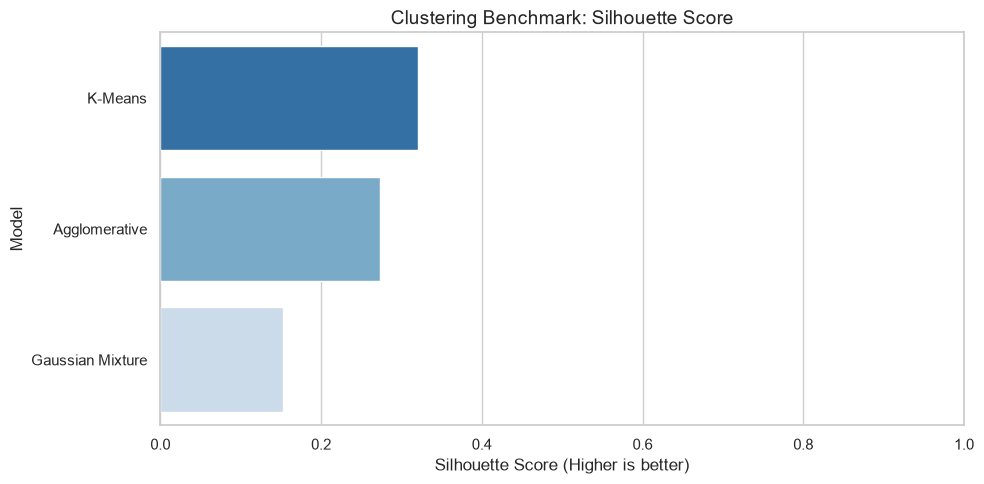

In [10]:
# Define the benchmark clustering models
benchmark_models = {
    'K-Means': KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init='auto'),
    'Gaussian Mixture': GaussianMixture(n_components=OPTIMAL_K, random_state=RANDOM_STATE),
    'Agglomerative': AgglomerativeClustering(n_clusters=OPTIMAL_K)
}

# Trains multiple models on the already preprocessed data and evaluates them.
def run_clustering_benchmark(models_dict, X_processed):
    results = []

    for name, model in models_dict.items():
        print(f"Evaluating {name}...")
        labels = model.fit_predict(X_processed)

        # Metrics are only defined if there is more than one cluster
        if len(np.unique(labels)) > 1:
            sil_score = silhouette_score(X_processed, labels)
            ch_score = calinski_harabasz_score(X_processed, labels)
            db_score = davies_bouldin_score(X_processed, labels)
        else:
            sil_score, ch_score, db_score = -1.0, 0.0, np.inf

        results.append({
            'Model': name,
            'Silhouette_Score': sil_score,
            'Calinski_Harabasz': ch_score,
            'Davies_Bouldin': db_score
        })

    # Sort prioritizing Silhouette Score
    return pd.DataFrame(results).sort_values(by='Silhouette_Score', ascending=False).reset_index(drop=True)

benchmark_results = run_clustering_benchmark(benchmark_models, X_processed)
display(benchmark_results)

# Plot Benchmark Results
plt.figure(figsize=(10, 5))
sns.barplot(data=benchmark_results, x='Silhouette_Score', y='Model', hue='Model', palette='Blues_r', legend=False)
plt.title("Clustering Benchmark: Silhouette Score", fontsize=14)
plt.xlabel("Silhouette Score (Higher is better)")
plt.ylabel("Model")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

## 11. Hyperparameter Optimization with Optuna
Automatically selects the best clustering algorithm from the benchmark and optimizes its hyperparameters, with the number of clusters fixed to the consensus `k`. Robustness checks penalize degenerate or heavily imbalanced solutions.

The tuned configuration is **adopted only if it beats the benchmark baseline** by a minimum margin on the same penalized objective. Otherwise the simpler baseline configuration is kept: tuning is a hypothesis to be tested, not a step that must always change the model.

In [11]:
# Dynamically identify the best clustering model from the benchmarking step
best_model_name = benchmark_results.iloc[0]['Model']
print(f"Best model automatically selected for tuning: {best_model_name}")

# Returns the hyperparameter search space specific to the selected clustering model.
def get_optuna_params(trial, model_name):
    if model_name == 'K-Means':
        return {
            'n_init': trial.suggest_int('n_init', 10, 50),
            'init': trial.suggest_categorical('init', ['k-means++', 'random'])
        }
    elif model_name == 'Gaussian Mixture':
        return {
            'covariance_type': trial.suggest_categorical('covariance_type', ['full', 'tied', 'diag', 'spherical']),
            'n_init': trial.suggest_int('n_init', 1, 5)
        }
    elif model_name == 'Agglomerative':
        return {
            'linkage': trial.suggest_categorical('linkage', ['ward', 'complete', 'average'])
        }
    return {}

# Creates a clustering model instance with k clusters and the optimized parameters.
def get_model_instance(model_name, dynamic_params, n_clusters=OPTIMAL_K, random_state=RANDOM_STATE):
    if model_name == 'K-Means':
        return KMeans(n_clusters=n_clusters, random_state=random_state, **dynamic_params)
    elif model_name == 'Gaussian Mixture':
        return GaussianMixture(n_components=n_clusters, random_state=random_state, **dynamic_params)
    elif model_name == 'Agglomerative':
        return AgglomerativeClustering(n_clusters=n_clusters, **dynamic_params)
    raise ValueError(f"Unsupported model: {model_name}")

# Silhouette with robustness penalties, shared by the tuning objective and the baseline comparison.
def penalized_silhouette(X_processed, labels):
    unique_labels, counts = np.unique(labels, return_counts=True)

    # Penalize if it generates less than 2 clusters or too many clusters relative to data size
    if len(unique_labels) < 2 or len(unique_labels) > (X_processed.shape[0] / 3):
        return -1.0

    score = silhouette_score(X_processed, labels)

    # Apply a penalty for heavily imbalanced clusters (e.g. less than 1% of total data)
    if counts.min() / X_processed.shape[0] < 0.01:
        score -= 0.1
    return score

# Objective function optimized by Optuna (the preprocessed matrix is reused across trials).
def objective(trial, model_name, X_processed):
    model = get_model_instance(model_name, get_optuna_params(trial, model_name))
    return penalized_silhouette(X_processed, model.fit_predict(X_processed))

# Run Optuna (seeded sampler for reproducibility)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
print(f"\nStarting Optuna Optimization for {best_model_name} (k = {OPTIMAL_K})...")
study.optimize(lambda trial: objective(trial, best_model_name, X_processed), n_trials=30)

# Adopt the tuned configuration only if it clearly beats the baseline on the same objective
MIN_GAIN = 0.005
baseline_model = clone(benchmark_models[best_model_name])
baseline_score = penalized_silhouette(X_processed, baseline_model.fit_predict(X_processed))
tuning_gain = study.best_value - baseline_score

if tuning_gain > MIN_GAIN:
    final_model_template = get_model_instance(best_model_name, study.best_params)
    config_source = "Optuna"
else:
    final_model_template = clone(benchmark_models[best_model_name])
    config_source = "Baseline (tuning gain below threshold)"

print("\nOptimization Completed")
print(f"Best Optuna Parameters         : {study.best_params}")
print(f"Baseline Score (Penalized)     : {baseline_score:.4f}")
print(f"Best Optuna Score (Penalized)  : {study.best_value:.4f}")
print(f"Gain vs. Baseline              : {tuning_gain:+.4f} (minimum required: {MIN_GAIN})")
print(f"Adopted Configuration          : {config_source}")

Best model automatically selected for tuning: K-Means

Starting Optuna Optimization for K-Means (k = 3)...



Optimization Completed
Best Optuna Parameters         : {'n_init': 25, 'init': 'k-means++'}
Baseline Score (Penalized)     : 0.3211
Best Optuna Score (Penalized)  : 0.3212
Gain vs. Baseline              : +0.0001 (minimum required: 0.005)
Adopted Configuration          : Baseline (tuning gain below threshold)


## 12. Final Model Training
Trains the adopted configuration. Cluster IDs are then **re-ordered by average monetary value** (cluster 0 = highest value), so the IDs carry business meaning and stay stable across runs.

In [12]:
best_model = clone(final_model_template)
raw_labels = best_model.fit_predict(X_processed)

# Re-order cluster IDs by average monetary value (0 = most valuable)
value_order = pd.Series(customers["monetary"].values).groupby(raw_labels).mean().sort_values(ascending=False).index
relabel = {old: new for new, old in enumerate(value_order)}
labels_final = np.vectorize(relabel.get)(raw_labels)

df_clusters = data_pipeline.named_steps['feat_eng'].transform(customers)
df_clusters["cluster"] = labels_final

print("\nFinal Model Summary")
print("-" * 50)
print(f"Selected Algorithm : {best_model_name}")
print(f"Configuration      : {config_source}")
print(f"Model Parameters   : {best_model.get_params()}")
print(f"Consensus k        : {OPTIMAL_K}")
print(f"Number of Clusters : {len(np.unique(labels_final))}")


Final Model Summary
--------------------------------------------------
Selected Algorithm : K-Means
Configuration      : Baseline (tuning gain below threshold)
Model Parameters   : {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 'auto', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}
Consensus k        : 3
Number of Clusters : 3


## 13. Internal Cluster Validation
Evaluates the final clustering quality using multiple robust internal validation metrics.

In [13]:
sil_score = silhouette_score(X_processed, labels_final)
ch_score = calinski_harabasz_score(X_processed, labels_final)
db_score = davies_bouldin_score(X_processed, labels_final)

validation_metrics = pd.DataFrame({
    "Metric": ["Silhouette Score", "Calinski-Harabasz Index", "Davies-Bouldin Index"],
    "Value": [sil_score, ch_score, db_score]
})
print("\nInternal Validation Metrics")
print("-" * 50)

display(validation_metrics)


Internal Validation Metrics
--------------------------------------------------


,Metric,Value
0,Silhouette Score,0.321059
1,Calinski-Harabasz Index,1561.847839
2,Davies-Bouldin Index,1.150261


## 14. Clustering Stability Assessment
Measures clustering robustness with a subsampling approach: the final model is refitted on 10 random subsamples (80% of the customers, with a different seed for stochastic models) and each result is compared against the final labels on the same customers using the Adjusted Rand Index (ARI).

In [14]:
n_runs, sample_frac = 10, 0.8
rng = np.random.default_rng(RANDOM_STATE)
n_samples = X_processed.shape[0]
ari_scores = []

for run in range(n_runs):
    idx = rng.choice(n_samples, size=int(sample_frac * n_samples), replace=False)
    model = clone(final_model_template)
    if 'random_state' in model.get_params():
        model.set_params(random_state=run)
    labels_sub = model.fit_predict(X_processed[idx])
    ari_scores.append(adjusted_rand_score(labels_final[idx], labels_sub))

print("\nCluster Stability Assessment (Subsampling ARI)")
print("-" * 50)
print(f"Runs     : {n_runs} x {sample_frac:.0%} subsamples")
print(f"Mean ARI : {np.mean(ari_scores):.4f}")
print(f"Std ARI  : {np.std(ari_scores):.4f}")
print(f"Min ARI  : {np.min(ari_scores):.4f}")


Cluster Stability Assessment (Subsampling ARI)
--------------------------------------------------
Runs     : 10 x 80% subsamples
Mean ARI : 0.9824
Std ARI  : 0.0156
Min ARI  : 0.9375


## 15. Cluster Distribution Analysis
Reviews cluster balance and identifies potential outlier groups or micro-clusters.


Cluster Distribution
--------------------------------------------------


,Cluster,Customers,Percentage
0,0,1117,33.8
1,1,549,16.6
2,2,1639,49.6


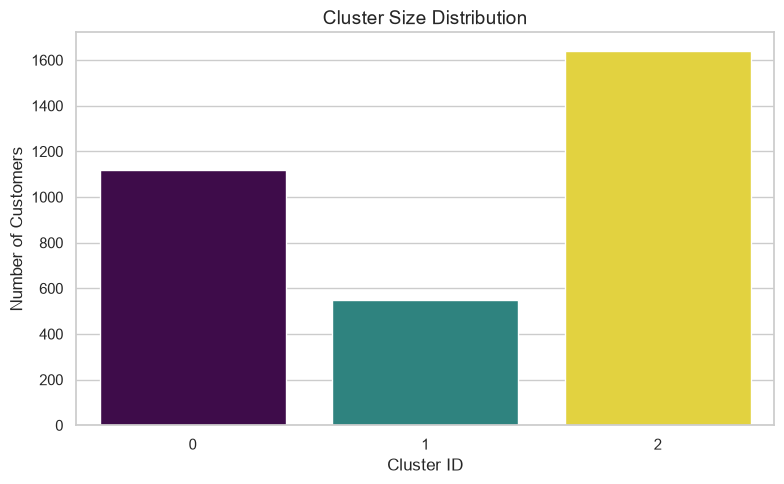

In [15]:
cluster_distribution = pd.Series(labels_final).value_counts().sort_index().reset_index()
cluster_distribution.columns = ["Cluster", "Customers"]
cluster_distribution["Percentage"] = (cluster_distribution["Customers"] / cluster_distribution["Customers"].sum() * 100).round(1)

print("\nCluster Distribution")
print("-" * 50)
display(cluster_distribution)

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_distribution, x="Cluster", y="Customers", hue="Cluster", palette="viridis", legend=False)
plt.title("Cluster Size Distribution", fontsize=14)
plt.xlabel("Cluster ID")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 16. Advanced Cluster Visualizations (PCA & Feature Diagnostics)
Visualizes the final clusters within a reduced dimensional space (PCA) and explores how the behavioral features behave across segments (log scale, since the features are heavily skewed).

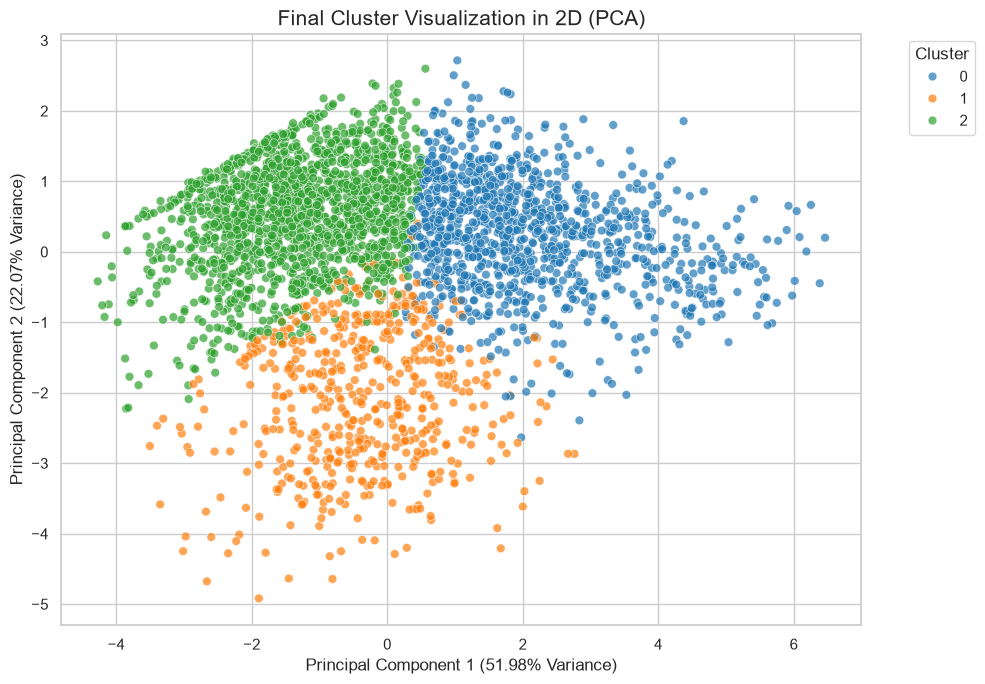

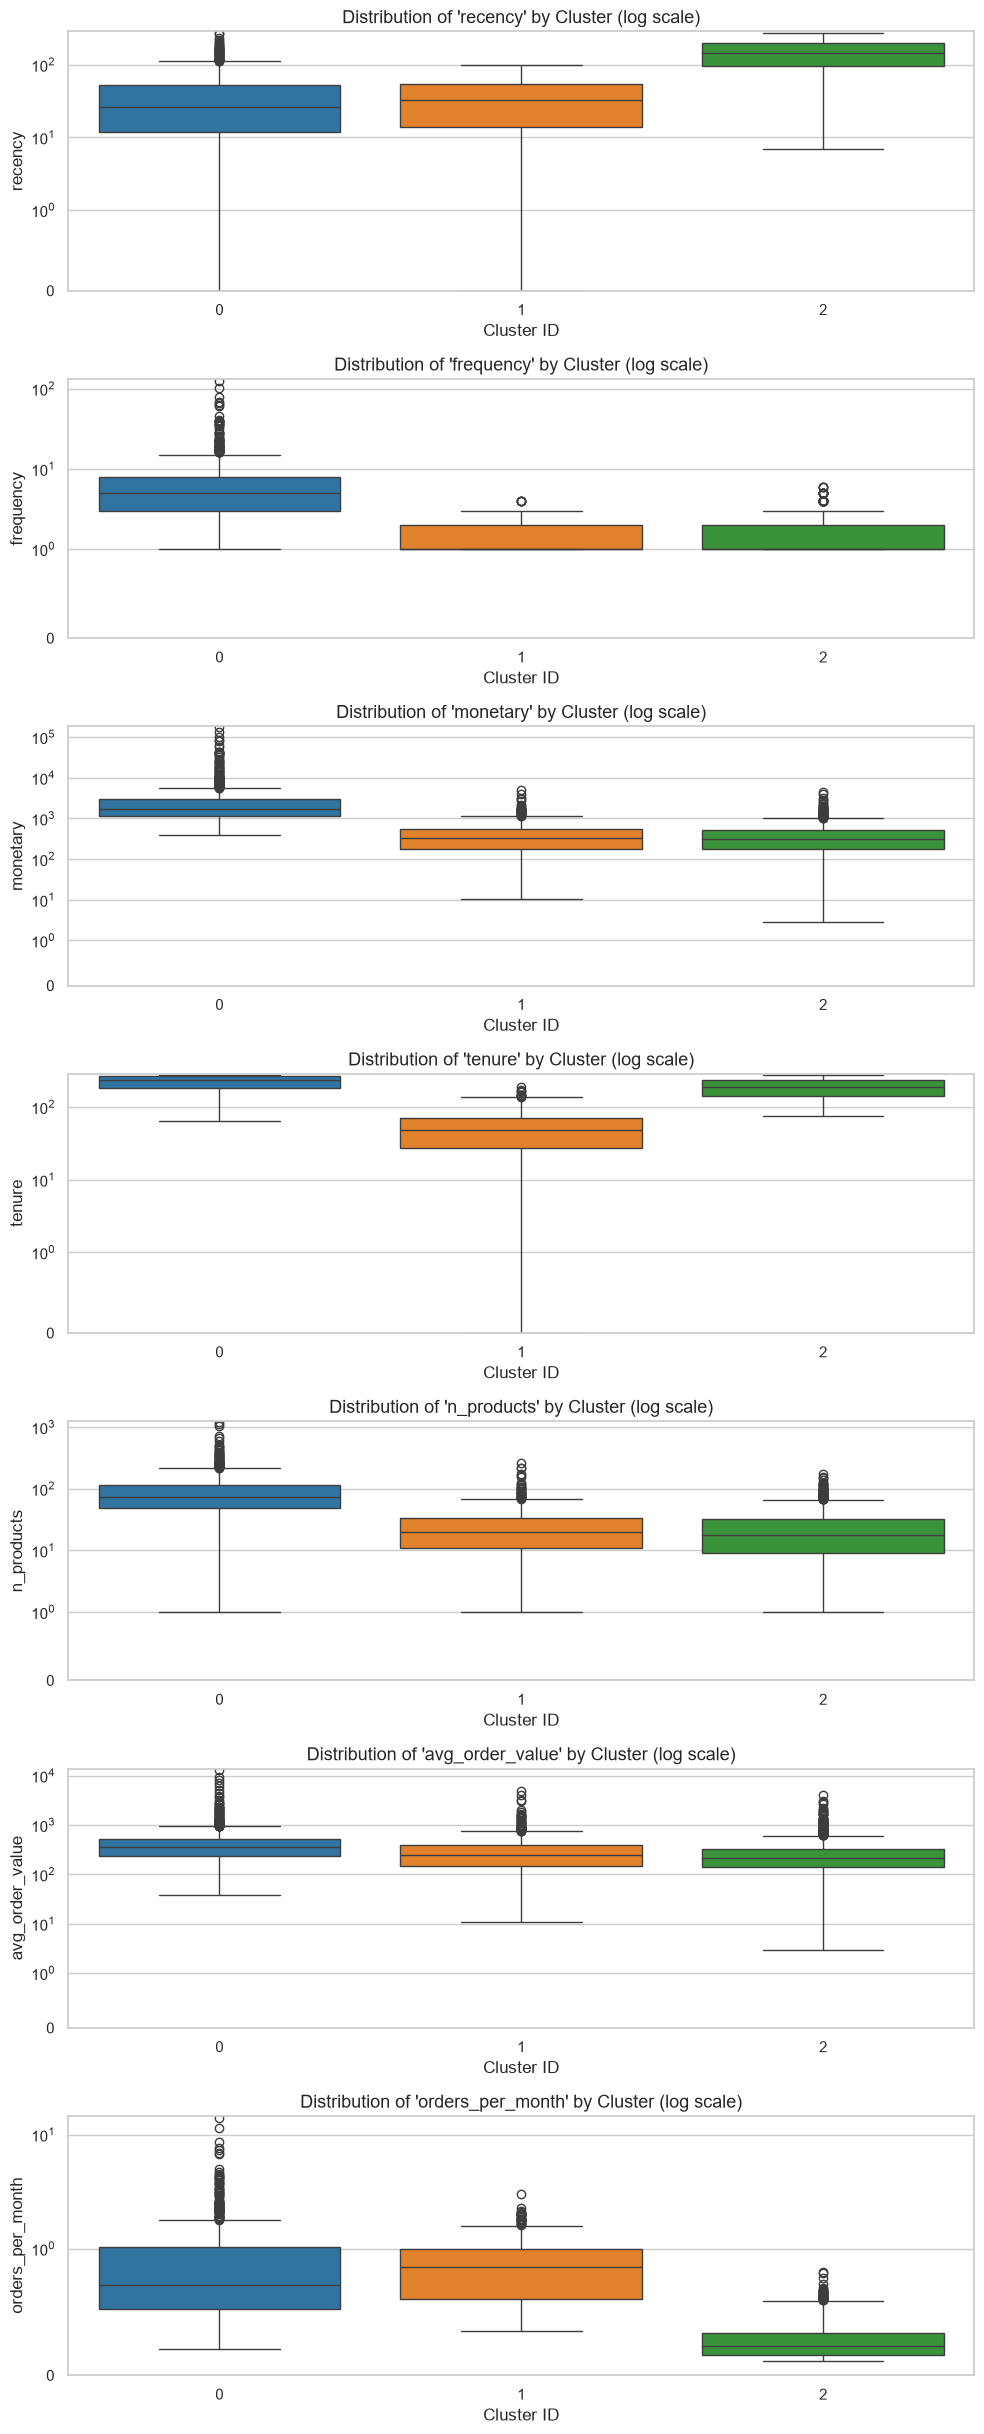

In [16]:
# PCA visualization of Final Clusters
final_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_final = final_pca.fit_transform(X_processed)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca_final[:, 0], y=X_pca_final[:, 1],
    hue=labels_final, palette='tab10', s=40, alpha=0.7, edgecolor='w'
)
plt.title("Final Cluster Visualization in 2D (PCA)", fontsize=15)
plt.xlabel(f"Principal Component 1 ({final_pca.explained_variance_ratio_[0]:.2%} Variance)")
plt.ylabel(f"Principal Component 2 ({final_pca.explained_variance_ratio_[1]:.2%} Variance)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Feature distribution profiling across clusters (all behavioral features)
fig, axes = plt.subplots(len(BEHAVIOR_FEATURES), 1, figsize=(10, 3.5 * len(BEHAVIOR_FEATURES)))
axes = np.atleast_1d(axes)

for ax, feature in zip(axes, BEHAVIOR_FEATURES):
    sns.boxplot(x=labels_final, y=df_clusters[feature], hue=labels_final, ax=ax, palette='tab10', legend=False)
    ax.set_yscale('symlog', linthresh=1)
    ax.set_ylim(bottom=0)
    ax.set_title(f"Distribution of '{feature}' by Cluster (log scale)", fontsize=13)
    ax.set_xlabel("Cluster ID")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 17. Temporal Validation: Do the Segments Anticipate Future Revenue?
The outcome window (never seen by the model) is joined to each customer. If the segmentation captures real behavior, the segments should differ strongly in **how many customers purchase again** and **how much revenue they generate** in the following months.


Temporal Validation (outcome window: after the cutoff date)
--------------------------------------------------
Overall repurchase rate: 58.8%


,customers,repurchase_rate,avg_future_revenue,share_of_customers,share_of_future_revenue
cluster,,,,,
0,1117,0.842,1897.981,0.338,0.777
1,549,0.512,409.457,0.166,0.082
2,1639,0.441,234.133,0.496,0.141


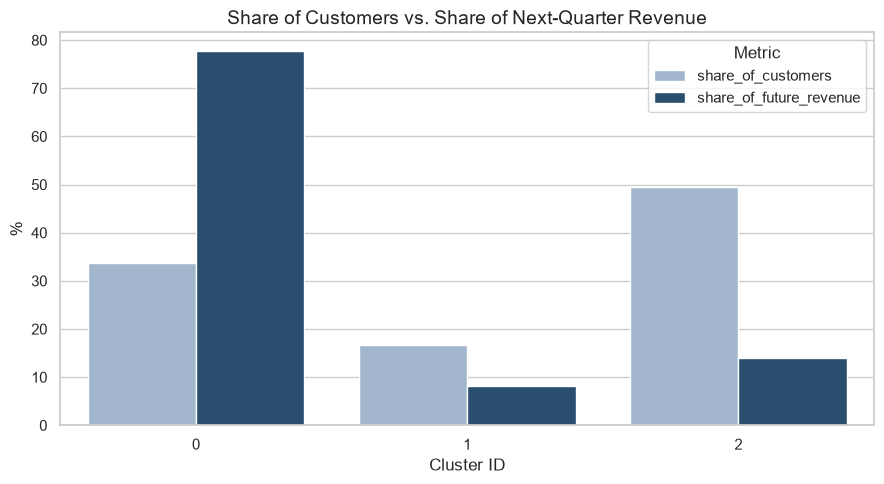

In [17]:
future = pd.DataFrame({
    "future_revenue": outcome.groupby("customer_id")["revenue"].sum(),  # Net of cancellations
    "future_orders": outcome[~outcome["is_cancellation"]].groupby("customer_id")["invoice_no"].nunique()
})
df_clusters = df_clusters.join(future).fillna({"future_revenue": 0, "future_orders": 0})
df_clusters["purchased_again"] = df_clusters["future_orders"] > 0

temporal_validation = df_clusters.groupby("cluster").agg(
    customers=("purchased_again", "size"),
    repurchase_rate=("purchased_again", "mean"),
    avg_future_revenue=("future_revenue", "mean")
)
temporal_validation["share_of_customers"] = temporal_validation["customers"] / temporal_validation["customers"].sum()
temporal_validation["share_of_future_revenue"] = (
    df_clusters.groupby("cluster")["future_revenue"].sum() / df_clusters["future_revenue"].sum()
)

print("\nTemporal Validation (outcome window: after the cutoff date)")
print("-" * 50)
print(f"Overall repurchase rate: {df_clusters['purchased_again'].mean():.1%}")
display(temporal_validation.round(3))

# Share of customers vs. share of future revenue per cluster
shares = temporal_validation[["share_of_customers", "share_of_future_revenue"]].mul(100).reset_index().melt(
    id_vars="cluster", var_name="Metric", value_name="Percentage")
plt.figure(figsize=(9, 5))
sns.barplot(data=shares, x="cluster", y="Percentage", hue="Metric", palette=["#9bb7d4", "#1f4e79"])
plt.title("Share of Customers vs. Share of Next-Quarter Revenue", fontsize=14)
plt.xlabel("Cluster ID")
plt.ylabel("%")
plt.tight_layout()
plt.show()

## 18. Cluster Profiling (Business Personas)
Median profile of each cluster in the original units, plus the market mix (countries with less than 5% of customers grouped as "Other" by `RareCategoryEncoder`), to translate the clusters into actionable customer personas.

In [18]:
# Group rare countries to profile the market mix of each segment
country_encoder = RareCategoryEncoder(threshold=0.05).fit(df_clusters[["country"]])
df_clusters["market"] = country_encoder.transform(df_clusters[["country"]]).ravel()

cluster_profile = df_clusters.groupby("cluster")[BEHAVIOR_FEATURES].median()
cluster_profile["customers"] = df_clusters["cluster"].value_counts().sort_index()
cluster_profile = cluster_profile.join(pd.crosstab(df_clusters["cluster"], df_clusters["market"], normalize="index").add_prefix("share_"))

display(cluster_profile.round(2))

,recency,frequency,monetary,tenure,n_products,avg_order_value,orders_per_month,customers,share_Other,share_United Kingdom
cluster,,,,,,,,,,
0,26.0,5.0,1748.88,232.0,74.0,350.18,0.71,1117,0.11,0.89
1,33.0,1.0,329.67,48.0,20.0,242.09,0.86,549,0.13,0.87
2,143.0,1.0,312.23,187.0,18.0,218.80,0.23,1639,0.08,0.92


**Reading the segments (medians in the observation window, outcomes in the following quarter):**

| Cluster | Persona | Behavioral profile | Next quarter | Recommended action |
|---|---|---|---|---|
| 0 | **Loyal core** (33.8% of customers) | Last purchase 26 days ago, 5 orders, GBP 1,749 net spent, 74 distinct products, active for 232 days | 84.2% bought again and generated 77.7% of the net revenue | Retention: account management, early access, volume-based loyalty benefits |
| 1 | **New customers** (16.6%) | Active for only 48 days, 1 order, GBP 330 net spent | 51.2% bought again, 8.2% of the net revenue | Onboarding: incentive for the second order, product recommendations |
| 2 | **Lapsed one-timers** (49.6%) | Last purchase 143 days ago, 1 order, GBP 312 net spent, first seen 187 days ago | 44.1% bought again, 14.1% of the net revenue | Low-cost reactivation: automated win-back campaigns, seasonal reminders |

One third of the customer base generates more than three quarters of the next-quarter revenue, while half of the base consists of customers who bought once and went quiet. The value of the segmentation is not in the Silhouette Score (0.32, typical for continuous behavioral data) but in how sharply the segments separate future behavior.